# E7 Central Error Analysis Notebook

Notebook này phân tích vì sao class **Central** khó hơn `Northern` và `Southern` trong thí nghiệm E7 PhoWhisper + CNN fusion.

Mục tiêu không phải suy luận quê quán, danh tính, hoặc thông tin cá nhân của người nói. Mục tiêu là tìm bằng chứng kỹ thuật ở mức dataset/model để trả lời:

- Central có ít dữ liệu hơn hoặc đa dạng hơn không?
- Central có phân phối thời lượng/chất lượng audio khác hai class còn lại không?
- Feature âm học của Central có overlap với Northern/Southern không?
- Confusion matrix E7 cho thấy Central bị kéo về phía nào?
- Nếu chạy phần tùy chọn, embedding/prediction của E7 có cho thấy nhánh global/local/fused làm Central khó ở đâu không?

Notebook mặc định chạy các phần nhẹ và ghi kết quả ra:

- `outputs/figures/e7_central_error_analysis/`
- `outputs/metrics/e7_central_error_analysis_audio_features.csv`
- `outputs/reports/e7_central_error_analysis.md`

Phần E7 forward để lấy confidence/embedding được để `RUN_E7_FORWARD = False` mặc định vì tốn thời gian và cần PhoWhisper checkpoint trong cache. Bật lên khi cần phân tích sâu hơn.

## 0. Thiết lập môi trường và đường dẫn

Cell dưới đây giúp notebook chạy được từ thư mục gốc repo hoặc từ `notebooks/`. Notebook chỉ dùng dependencies đã có trong project: `numpy`, `matplotlib`, `scikit-learn`, `soundfile`, `torch`, `transformers` cho phần tùy chọn.

In [1]:
from __future__ import annotations

import csv
import json
import math
import os
import random
import sys
import tempfile
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "vimd_e7_central_analysis_matplotlib"),
)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.preprocessing import StandardScaler


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "PLAN.md").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root containing PLAN.md and src/.")


ROOT = find_repo_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

LABELS = ["Northern", "Central", "Southern"]
LABEL_TO_INDEX = {label: index for index, label in enumerate(LABELS)}

METADATA_PATH = ROOT / "data/processed/preprocessed_metadata.csv"
RESULTS_PATH = ROOT / "outputs/metrics/e7_whisper_cnn_fusion_results.json"
TEST_CONFUSION_PATH = ROOT / "outputs/metrics/e7_whisper_cnn_fusion_test_confusion_matrix.csv"
VALID_CONFUSION_PATH = ROOT / "outputs/metrics/e7_whisper_cnn_fusion_valid_confusion_matrix.csv"
CHECKPOINT_PATH = ROOT / "outputs/models/e7_whisper_cnn_fusion.pt"
FIG_DIR = ROOT / "outputs/figures/e7_central_error_analysis"
METRICS_DIR = ROOT / "outputs/metrics"
REPORT_PATH = ROOT / "outputs/reports/e7_central_error_analysis.md"
AUDIO_FEATURE_CSV = METRICS_DIR / "e7_central_error_analysis_audio_features.csv"
PREDICTION_CSV = METRICS_DIR / "e7_central_error_analysis_predictions.csv"
EMBEDDING_NPZ = METRICS_DIR / "e7_central_error_analysis_embeddings.npz"

FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"repo root: {ROOT}")
print(f"metadata exists: {METADATA_PATH.exists()} -> {METADATA_PATH}")
print(f"E7 results exists: {RESULTS_PATH.exists()} -> {RESULTS_PATH}")
print(f"E7 checkpoint exists: {CHECKPOINT_PATH.exists()} -> {CHECKPOINT_PATH}")

repo root: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application
metadata exists: True -> /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/data/processed/preprocessed_metadata.csv
E7 results exists: True -> /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/metrics/e7_whisper_cnn_fusion_results.json
E7 checkpoint exists: True -> /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/models/e7_whisper_cnn_fusion.pt


## Helper functions

Các helper này cố tình đơn giản: đọc CSV/JSON, tạo bảng markdown, vẽ bar/box/scatter, và lưu figure. Notebook không dùng pandas để giữ đúng dependency nhẹ của repo.

In [2]:
def read_csv_rows(path: Path) -> list[dict[str, str]]:
    if not path.exists():
        raise FileNotFoundError(path)
    with path.open(newline="", encoding="utf-8") as input_file:
        return list(csv.DictReader(input_file))


def read_json(path: Path) -> dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(path)
    return json.loads(path.read_text(encoding="utf-8"))


def as_float(value: Any, default: float = float("nan")) -> float:
    try:
        if value in (None, ""):
            return default
        return float(value)
    except (TypeError, ValueError):
        return default


def markdown_table(headers: list[str], rows: list[list[Any]], float_digits: int = 4) -> str:
    def format_value(value: Any) -> str:
        if isinstance(value, float):
            if math.isnan(value):
                return "nan"
            return f"{value:.{float_digits}f}"
        return str(value)

    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        lines.append("| " + " | ".join(format_value(value) for value in row) + " |")
    return "\n".join(lines)


def display_table(headers: list[str], rows: list[list[Any]], float_digits: int = 4) -> None:
    display(Markdown(markdown_table(headers, rows, float_digits=float_digits)))


def save_current_figure(name: str) -> Path:
    path = FIG_DIR / name
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"saved: {path}")
    return path


def load_confusion_matrix(path: Path) -> tuple[list[str], np.ndarray]:
    rows = list(csv.reader(path.open(newline="", encoding="utf-8")))
    if not rows:
        raise ValueError(f"Empty confusion matrix CSV: {path}")
    labels = [header.replace("pred_", "") for header in rows[0][1:]]
    matrix_rows = []
    true_labels = []
    for row in rows[1:]:
        if not row:
            continue
        true_labels.append(row[0])
        matrix_rows.append([int(value) for value in row[1:]])
    if true_labels:
        labels = true_labels
    matrix = np.asarray(matrix_rows, dtype=int)
    if matrix.shape != (len(labels), len(labels)):
        raise ValueError(f"Unexpected matrix shape {matrix.shape} for labels {labels}")
    return labels, matrix


def expand_confusion_matrix(matrix: np.ndarray) -> tuple[list[int], list[int]]:
    true_indexes: list[int] = []
    pred_indexes: list[int] = []
    for true_index in range(matrix.shape[0]):
        for pred_index in range(matrix.shape[1]):
            count = int(matrix[true_index, pred_index])
            true_indexes.extend([true_index] * count)
            pred_indexes.extend([pred_index] * count)
    return true_indexes, pred_indexes


def numeric_values(rows: list[dict[str, Any]], column: str) -> list[float]:
    values = [as_float(row.get(column)) for row in rows]
    return [value for value in values if np.isfinite(value)]


def summarize_numeric_by_label(rows: list[dict[str, Any]], column: str) -> list[list[Any]]:
    summary_rows: list[list[Any]] = []
    for label in LABELS:
        values = numeric_values([row for row in rows if row.get("label") == label], column)
        if not values:
            summary_rows.append([label, 0, float("nan"), float("nan"), float("nan"), float("nan")])
            continue
        array = np.asarray(values, dtype=float)
        summary_rows.append([
            label,
            len(values),
            float(np.mean(array)),
            float(np.median(array)),
            float(np.std(array)),
            float(np.percentile(array, 90) - np.percentile(array, 10)),
        ])
    return summary_rows


def plot_box_by_label(rows: list[dict[str, Any]], column: str, title: str, ylabel: str, output_name: str) -> Path | None:
    data = [numeric_values([row for row in rows if row.get("label") == label], column) for label in LABELS]
    if not any(data):
        print(f"skip {column}: no numeric values")
        return None
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data, labels=LABELS, showfliers=False)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(axis="y", alpha=0.25)
    path = save_current_figure(output_name)
    plt.show()
    return path


def entropy(counter: Counter[str]) -> float:
    total = sum(counter.values())
    if total <= 0:
        return 0.0
    probs = np.asarray([count / total for count in counter.values() if count > 0], dtype=float)
    return float(-(probs * np.log2(probs)).sum())


def safe_row_path(row: dict[str, str], column: str = "preprocessed_audio_path") -> Path:
    value = row.get(column, "")
    path = Path(value)
    return path if path.is_absolute() else ROOT / path

## 1. E7 hiện tại đang sai Central như thế nào?

Ta bắt đầu từ confusion matrix test của E7 mới. Nếu Central khó hơn, dấu hiệu thường thấy là **Central recall thấp**: nhiều mẫu thật là Central nhưng bị đẩy sang Northern hoặc Southern. Precision Central cao nhưng recall thấp nghĩa là model chỉ chọn Central khi khá chắc, còn phần mơ hồ bị hút sang class khác.

### E7 run metadata

- `trainable_setting`: `frozen_whisper_encoder_lightly_finetuned_efficientnetb0_trainable_fusion_head`
- local encoder: `lightly_finetuned_e2_efficientnetb0_features`
- CNN trainable layers: `2`
- CNN trainable child modules: `['5', '6']`
- local CNN trainable params: `69400`
- best epoch: `7`


| label | precision | recall | f1 | support |
| --- | --- | --- | --- | --- |
| Northern | 0.8198 | 0.9547 | 0.8821 | 486 |
| Central | 0.8136 | 0.5914 | 0.6849 | 487 |
| Southern | 0.7770 | 0.8619 | 0.8172 | 485 |

**Overall:** accuracy `0.8025`, macro F1 `0.7947`.  
**Central errors:** Central -> Northern `85`, Central -> Southern `114`.

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/e7_test_confusion_matrix.png


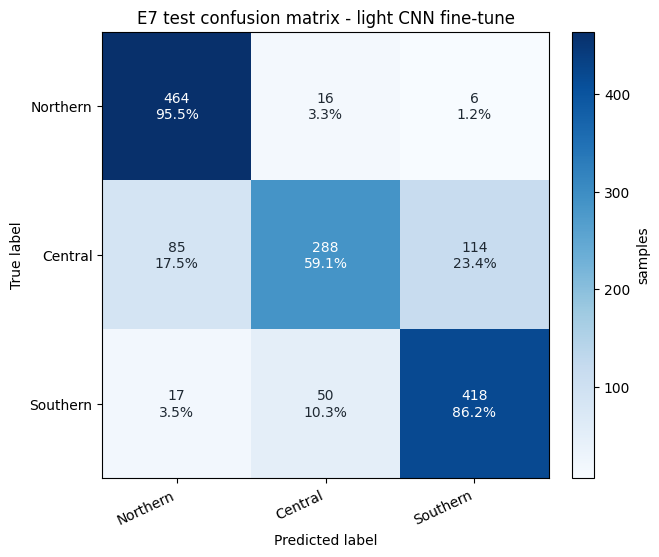

In [3]:
results = read_json(RESULTS_PATH)
labels, test_matrix = load_confusion_matrix(TEST_CONFUSION_PATH)
true_indexes, pred_indexes = expand_confusion_matrix(test_matrix)
report = classification_report(
    true_indexes,
    pred_indexes,
    labels=list(range(len(labels))),
    target_names=labels,
    output_dict=True,
    zero_division=0,
)
accuracy = float(accuracy_score(true_indexes, pred_indexes))
macro_f1 = float(f1_score(true_indexes, pred_indexes, average="macro"))
central_index = labels.index("Central")
central_to_northern = int(test_matrix[central_index, labels.index("Northern")])
central_to_southern = int(test_matrix[central_index, labels.index("Southern")])

display(Markdown(
    "### E7 run metadata\n\n"
    f"- `trainable_setting`: `{results.get('trainable_setting')}`\n"
    f"- local encoder: `{results.get('feature', {}).get('local_encoder')}`\n"
    f"- CNN trainable layers: `{results.get('training', {}).get('cnn_trainable_layers')}`\n"
    f"- CNN trainable child modules: `{results.get('training', {}).get('cnn_trainable_child_names')}`\n"
    f"- local CNN trainable params: `{results.get('parameter_counts', {}).get('local_encoder_trainable')}`\n"
    f"- best epoch: `{results.get('best_epoch')}`\n"
))

metric_rows = []
for label in labels:
    item = report[label]
    metric_rows.append([label, item["precision"], item["recall"], item["f1-score"], int(item["support"])])
display_table(["label", "precision", "recall", "f1", "support"], metric_rows)
display(Markdown(
    f"**Overall:** accuracy `{accuracy:.4f}`, macro F1 `{macro_f1:.4f}`.  \n"
    f"**Central errors:** Central -> Northern `{central_to_northern}`, Central -> Southern `{central_to_southern}`."
))

row_totals = test_matrix.sum(axis=1, keepdims=True)
percent = np.divide(test_matrix, row_totals, out=np.zeros_like(test_matrix, dtype=float), where=row_totals != 0) * 100.0
plt.figure(figsize=(7.4, 5.8))
image = plt.imshow(test_matrix, cmap="Blues")
plt.title("E7 test confusion matrix - light CNN fine-tune")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(len(labels)), labels, rotation=25, ha="right")
plt.yticks(range(len(labels)), labels)
threshold = test_matrix.max() * 0.55
for i in range(test_matrix.shape[0]):
    for j in range(test_matrix.shape[1]):
        color = "white" if test_matrix[i, j] > threshold else "#1f2933"
        plt.text(j, i, f"{test_matrix[i, j]}\n{percent[i, j]:.1f}%", ha="center", va="center", color=color)
plt.colorbar(image, fraction=0.046, pad=0.04, label="samples")
confusion_figure_path = save_current_figure("e7_test_confusion_matrix.png")
plt.show()

## 2. Metadata: số lượng, speaker, province, gender

Nếu Central khó hơn, nguyên nhân có thể không nằm ở model trước tiên. Central có thể:

- có ít sample hơn,
- có ít hoặc nhiều speaker hơn,
- có nhiều province/sub-region nội bộ hơn,
- có phân phối gender hoặc source split khác,
- có nhiều mẫu từ các province sát ranh Northern/Southern nên dễ overlap.

Phần này không kết luận nhân quả, nhưng giúp kiểm tra các giả thuyết dữ liệu.

metadata rows with supported labels: 13,894


| split | Northern | Central | Southern |
| --- | --- | --- | --- |
| test | 486 | 487 | 485 |
| train | 3708 | 3416 | 3854 |
| valid | 486 | 487 | 485 |

| label | samples | unique_speakers | unique_provinces | male | female |
| --- | --- | --- | --- | --- | --- |
| Northern | 4680 | 3419 | 24 | 3291 | 1389 |
| Central | 4390 | 3022 | 19 | 3176 | 1214 |
| Southern | 4824 | 3101 | 19 | 3480 | 1344 |

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/metadata_samples_by_split_label.png


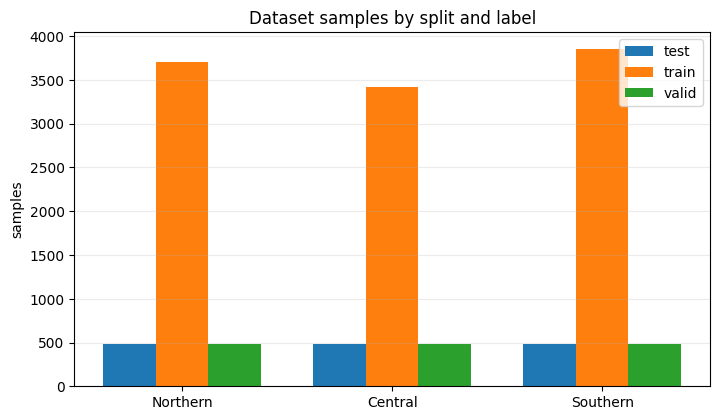

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/metadata_speaker_province_diversity.png


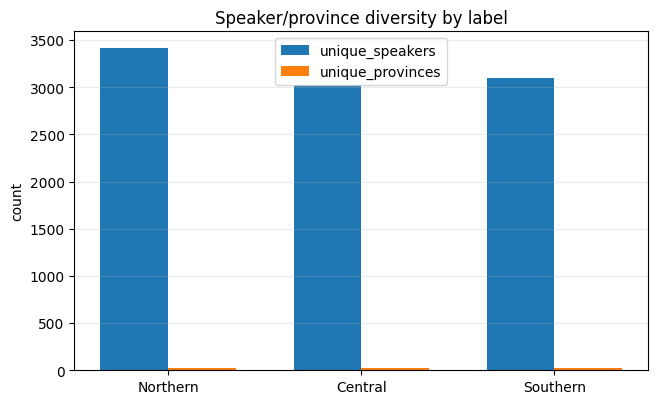

In [4]:
metadata_rows = read_csv_rows(METADATA_PATH)
metadata_rows = [row for row in metadata_rows if row.get("label") in LABELS]
print(f"metadata rows with supported labels: {len(metadata_rows):,}")

split_label_counts: dict[str, Counter[str]] = defaultdict(Counter)
for row in metadata_rows:
    split_label_counts[row.get("source_split", "unknown")][row["label"]] += 1

split_names = sorted(split_label_counts)
count_rows = []
for split in split_names:
    count_rows.append([split, *[split_label_counts[split][label] for label in LABELS]])
display_table(["split", *LABELS], count_rows, float_digits=0)

label_counts = Counter(row["label"] for row in metadata_rows)
unique_speakers = {
    label: len({row.get("speaker_id", "") for row in metadata_rows if row["label"] == label and row.get("speaker_id")})
    for label in LABELS
}
unique_provinces = {
    label: len({row.get("province_name", "") for row in metadata_rows if row["label"] == label and row.get("province_name")})
    for label in LABELS
}
gender_counts = defaultdict(Counter)
for row in metadata_rows:
    gender_counts[row["label"]][row.get("gender", "unknown") or "unknown"] += 1

summary_rows = []
for label in LABELS:
    summary_rows.append([
        label,
        label_counts[label],
        unique_speakers[label],
        unique_provinces[label],
        gender_counts[label].get("male", 0),
        gender_counts[label].get("female", 0),
    ])
display_table(["label", "samples", "unique_speakers", "unique_provinces", "male", "female"], summary_rows, float_digits=0)

x = np.arange(len(LABELS))
width = 0.25
plt.figure(figsize=(8.2, 4.6))
for offset, split in enumerate(split_names):
    values = [split_label_counts[split][label] for label in LABELS]
    plt.bar(x + (offset - (len(split_names) - 1) / 2) * width, values, width=width, label=split)
plt.xticks(x, LABELS)
plt.ylabel("samples")
plt.title("Dataset samples by split and label")
plt.legend()
plt.grid(axis="y", alpha=0.25)
samples_by_split_path = save_current_figure("metadata_samples_by_split_label.png")
plt.show()

plt.figure(figsize=(7.4, 4.4))
metric_names = ["unique_speakers", "unique_provinces"]
values_by_metric = [unique_speakers, unique_provinces]
bar_width = 0.35
for idx, (name, values) in enumerate(zip(metric_names, values_by_metric)):
    plt.bar(x + (idx - 0.5) * bar_width, [values[label] for label in LABELS], width=bar_width, label=name)
plt.xticks(x, LABELS)
plt.ylabel("count")
plt.title("Speaker/province diversity by label")
plt.legend()
plt.grid(axis="y", alpha=0.25)
diversity_path = save_current_figure("metadata_speaker_province_diversity.png")
plt.show()

## 3. Central có đa dạng nội bộ hơn không?

Central trong tiếng Việt thường có thể bao gồm nhiều vùng chuyển tiếp. Nếu dữ liệu Central trải rộng trên nhiều province hoặc speaker distribution lệch, model có thể học ranh giới khó hơn. Ta đo:

- province entropy: province càng phân tán thì entropy càng cao,
- số sample/speaker: nếu một class bị nhiều speaker ít mẫu hoặc một vài speaker áp đảo, model có thể khó tổng quát.

| label | province_count | province_entropy | normalized_entropy | top_province | top_count |
| --- | --- | --- | --- | --- | --- |
| Northern | 24 | 4.3920 | 0.9579 | CaoBang | 357 |
| Central | 19 | 4.1216 | 0.9703 | BinhThuan | 325 |
| Southern | 19 | 4.1969 | 0.9880 | BinhPhuoc | 319 |

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/central_top_provinces.png


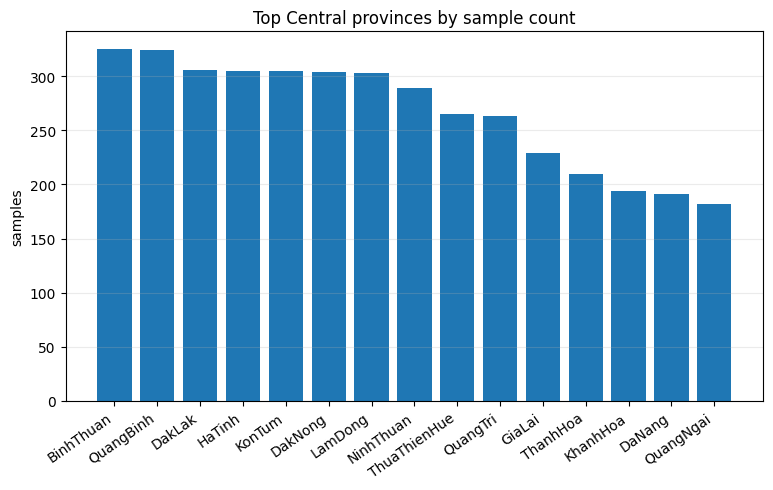

| label | speakers | mean_samples_per_speaker | median | max |
| --- | --- | --- | --- | --- |
| Northern | 3419 | 1.3688 | 1.0000 | 9 |
| Central | 3022 | 1.4527 | 1.0000 | 9 |
| Southern | 3101 | 1.5556 | 1.0000 | 8 |

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/speaker_samples_by_label_boxplot.png


/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/83945480.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([samples_per_speaker_by_label[label] for label in LABELS], labels=LABELS, showfliers=False)


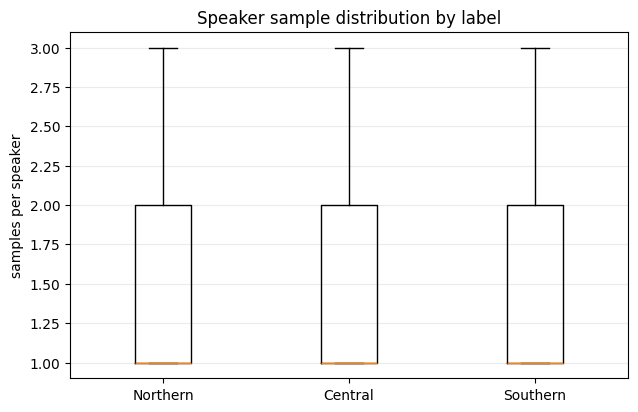

In [5]:
province_entropy_rows = []
for label in LABELS:
    province_counter = Counter(
        row.get("province_name", "unknown") or "unknown"
        for row in metadata_rows
        if row["label"] == label
    )
    max_entropy = math.log2(max(len(province_counter), 1))
    value = entropy(province_counter)
    province_entropy_rows.append([
        label,
        len(province_counter),
        value,
        value / max_entropy if max_entropy > 0 else 0.0,
        province_counter.most_common(1)[0][0] if province_counter else "none",
        province_counter.most_common(1)[0][1] if province_counter else 0,
    ])
display_table(["label", "province_count", "province_entropy", "normalized_entropy", "top_province", "top_count"], province_entropy_rows)

central_province_counter = Counter(
    row.get("province_name", "unknown") or "unknown"
    for row in metadata_rows
    if row["label"] == "Central"
)
top_central = central_province_counter.most_common(15)
plt.figure(figsize=(9, 4.8))
plt.bar([name for name, _count in top_central], [count for _name, count in top_central])
plt.xticks(rotation=35, ha="right")
plt.ylabel("samples")
plt.title("Top Central provinces by sample count")
plt.grid(axis="y", alpha=0.25)
central_province_path = save_current_figure("central_top_provinces.png")
plt.show()

speaker_stat_rows = []
samples_per_speaker_by_label: dict[str, list[int]] = {}
for label in LABELS:
    counter = Counter(
        row.get("speaker_id", "unknown") or "unknown"
        for row in metadata_rows
        if row["label"] == label
    )
    values = np.asarray(list(counter.values()), dtype=float)
    samples_per_speaker_by_label[label] = values.tolist()
    speaker_stat_rows.append([
        label,
        len(values),
        float(np.mean(values)) if len(values) else float("nan"),
        float(np.median(values)) if len(values) else float("nan"),
        int(np.max(values)) if len(values) else 0,
    ])
display_table(["label", "speakers", "mean_samples_per_speaker", "median", "max"], speaker_stat_rows)

plt.figure(figsize=(7.2, 4.5))
plt.boxplot([samples_per_speaker_by_label[label] for label in LABELS], labels=LABELS, showfliers=False)
plt.ylabel("samples per speaker")
plt.title("Speaker sample distribution by label")
plt.grid(axis="y", alpha=0.25)
speaker_box_path = save_current_figure("speaker_samples_by_label_boxplot.png")
plt.show()

## 4. Thời lượng và chất lượng audio từ metadata

Các cột metadata như `original_duration_seconds`, `preprocessed_rms`, `preprocessed_peak`, `audio_bytes` giúp kiểm tra nhanh chất lượng và điều kiện dữ liệu. Nếu Central có nhiều mẫu quá nhỏ, quá to, clipping cao, hoặc duration gốc khác biệt, model có thể bị nhiễu bởi yếu tố không phải dialect.

### `original_duration_seconds`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 4680 | 19.1602 | 19.0930 | 6.1210 | 16.3584 |
| Central | 4390 | 18.8944 | 18.8373 | 6.1371 | 16.6001 |
| Southern | 4824 | 19.3916 | 19.4396 | 6.6215 | 17.9992 |

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/metadata_original_duration_boxplot.png


/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


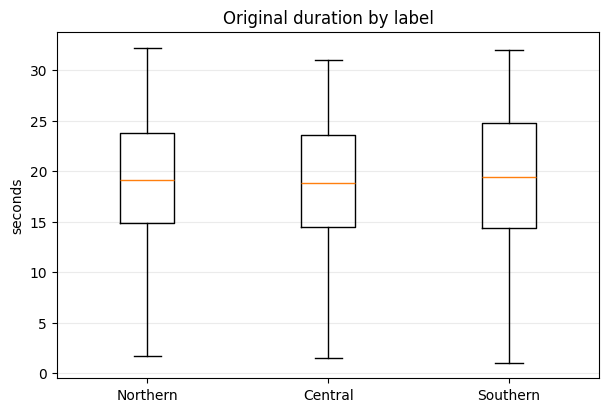

### `preprocessed_rms`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 4680 | 0.0745 | 0.0779 | 0.0093 | 0.0211 |
| Central | 4390 | 0.0744 | 0.0779 | 0.0092 | 0.0206 |
| Southern | 4824 | 0.0747 | 0.0779 | 0.0093 | 0.0216 |

/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/metadata_preprocessed_rms_boxplot.png


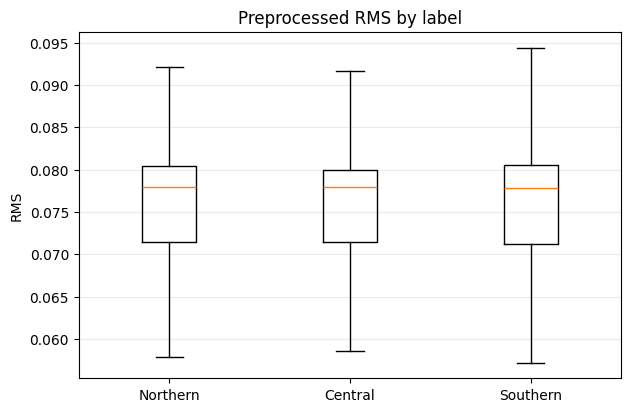

### `preprocessed_peak`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 4680 | 0.6954 | 0.6929 | 0.1935 | 0.5565 |
| Central | 4390 | 0.6644 | 0.6356 | 0.1735 | 0.4964 |
| Southern | 4824 | 0.6672 | 0.6562 | 0.1904 | 0.5382 |

/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/metadata_preprocessed_peak_boxplot.png


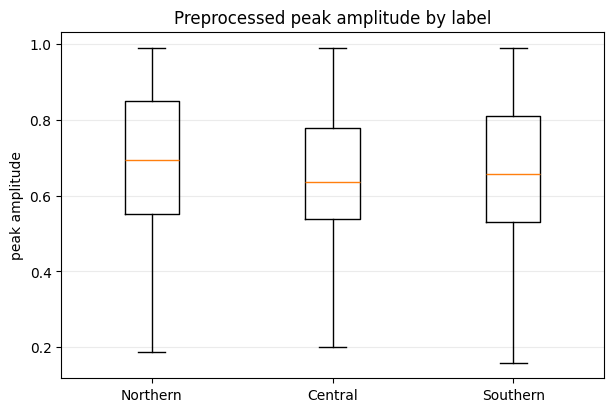

### `audio_bytes`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 4680 | 613168.8410 | 611020.0000 | 195872.7332 | 523467.6000 |
| Central | 4390 | 604664.3868 | 602837.0000 | 196386.1364 | 531203.6000 |
| Southern | 4824 | 620575.5626 | 622111.0000 | 211888.7415 | 575972.8000 |

/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/metadata_audio_bytes_boxplot.png


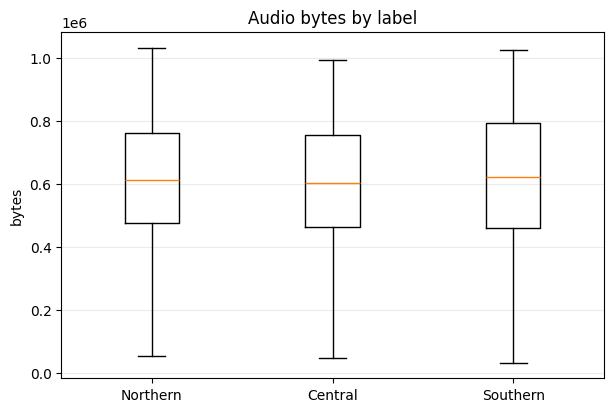

In [6]:
metadata_numeric_columns = [
    ("original_duration_seconds", "Original duration by label", "seconds", "metadata_original_duration_boxplot.png"),
    ("preprocessed_rms", "Preprocessed RMS by label", "RMS", "metadata_preprocessed_rms_boxplot.png"),
    ("preprocessed_peak", "Preprocessed peak amplitude by label", "peak amplitude", "metadata_preprocessed_peak_boxplot.png"),
    ("audio_bytes", "Audio bytes by label", "bytes", "metadata_audio_bytes_boxplot.png"),
]

for column, title, ylabel, filename in metadata_numeric_columns:
    display(Markdown(f"### `{column}`"))
    display_table(["label", "n", "mean", "median", "std", "p90_minus_p10"], summarize_numeric_by_label(metadata_rows, column))
    plot_box_by_label(metadata_rows, column, title, ylabel, filename)

## 5. Acoustic feature sample: Central có overlap âm học không?

Phần này lấy mẫu cân bằng theo class rồi tính feature âm học đơn giản từ audio đã preprocess:

- RMS, peak, zero-crossing rate,
- spectral centroid/bandwidth/flatness,
- log-Mel mean/std trước khi standardize,
- MFCC mean/std aggregation.

Mặc định notebook dùng `MAX_AUDIO_PER_LABEL = 80` để chạy nhanh. Tăng lên `None` nếu muốn chạy toàn bộ, hoặc giảm xuống vài mẫu để smoke test. Đây là phân tích mô tả, không thay thế training/evaluation chính thức.

In [7]:
RANDOM_SEED = 42
MAX_AUDIO_PER_LABEL: int | None = 80
AUDIO_FEATURE_SPLIT: str | None = None  # set to "test" if you only want the E7 test split
RECOMPUTE_AUDIO_FEATURES = False

from src.features.logmel import log_mel_spectrogram
from src.features.mfcc import mfcc_mean_std, power_spectrogram


def select_balanced_audio_rows(rows: list[dict[str, str]]) -> list[dict[str, str]]:
    rng = random.Random(RANDOM_SEED)
    filtered = [row for row in rows if row.get("label") in LABELS]
    if AUDIO_FEATURE_SPLIT is not None:
        filtered = [row for row in filtered if row.get("source_split") == AUDIO_FEATURE_SPLIT]
    selected: list[dict[str, str]] = []
    for label in LABELS:
        candidates = [row for row in filtered if row.get("label") == label and safe_row_path(row).exists()]
        rng.shuffle(candidates)
        if MAX_AUDIO_PER_LABEL is not None:
            candidates = candidates[:MAX_AUDIO_PER_LABEL]
        selected.extend(candidates)
    return selected


def read_waveform(path: Path) -> tuple[np.ndarray, int]:
    waveform, sample_rate = sf.read(path, always_2d=False)
    waveform = np.asarray(waveform, dtype=np.float32)
    if waveform.ndim == 2:
        waveform = waveform.mean(axis=1)
    return waveform, int(sample_rate)


def zero_crossing_rate(waveform: np.ndarray) -> float:
    if waveform.size < 2:
        return 0.0
    signs = np.signbit(waveform)
    return float(np.mean(signs[1:] != signs[:-1]))


def spectral_summary(waveform: np.ndarray, sample_rate: int) -> dict[str, float]:
    power = power_spectrogram(waveform)
    freqs = np.fft.rfftfreq(512, d=1.0 / sample_rate).astype(np.float64)
    energy = np.maximum(power.sum(axis=1).astype(np.float64), 1e-12)
    centroid = (power.astype(np.float64) * freqs[None, :]).sum(axis=1) / energy
    bandwidth = np.sqrt(((freqs[None, :] - centroid[:, None]) ** 2 * power.astype(np.float64)).sum(axis=1) / energy)
    geometric = np.exp(np.mean(np.log(np.maximum(power.astype(np.float64), 1e-12)), axis=1))
    arithmetic = np.maximum(np.mean(power.astype(np.float64), axis=1), 1e-12)
    flatness = geometric / arithmetic
    return {
        "spectral_centroid_mean": float(np.mean(centroid)),
        "spectral_centroid_std": float(np.std(centroid)),
        "spectral_bandwidth_mean": float(np.mean(bandwidth)),
        "spectral_bandwidth_std": float(np.std(bandwidth)),
        "spectral_flatness_mean": float(np.mean(flatness)),
    }


def compute_audio_feature_row(row: dict[str, str]) -> dict[str, Any]:
    path = safe_row_path(row)
    waveform, sample_rate = read_waveform(path)
    logmel_raw = log_mel_spectrogram(waveform, sample_rate=sample_rate, standardize=False)
    mfcc = mfcc_mean_std(waveform, sample_rate=sample_rate)
    feature_row: dict[str, Any] = {
        "sample_id": row.get("sample_id", ""),
        "source_split": row.get("source_split", ""),
        "label": row.get("label", ""),
        "province_name": row.get("province_name", ""),
        "speaker_id": row.get("speaker_id", ""),
        "gender": row.get("gender", ""),
        "audio_path": str(path.relative_to(ROOT) if path.is_relative_to(ROOT) else path),
        "sample_rate": sample_rate,
        "duration_seconds": float(waveform.size / max(sample_rate, 1)),
        "rms": float(np.sqrt(np.mean(np.square(waveform.astype(np.float64))))),
        "peak": float(np.max(np.abs(waveform))) if waveform.size else 0.0,
        "zcr": zero_crossing_rate(waveform),
        "logmel_mean": float(np.mean(logmel_raw)),
        "logmel_std": float(np.std(logmel_raw)),
    }
    feature_row.update(spectral_summary(waveform, sample_rate))
    for index, value in enumerate(mfcc[:13], start=1):
        feature_row[f"mfcc_{index}_mean"] = float(value)
    for index, value in enumerate(mfcc[13:], start=1):
        feature_row[f"mfcc_{index}_std"] = float(value)
    return feature_row


def write_feature_csv(path: Path, rows: list[dict[str, Any]]) -> None:
    if not rows:
        return
    fields = list(rows[0].keys())
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as output_file:
        writer = csv.DictWriter(output_file, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


def load_feature_csv(path: Path) -> list[dict[str, str]]:
    if not path.exists():
        return []
    return read_csv_rows(path)


if AUDIO_FEATURE_CSV.exists() and not RECOMPUTE_AUDIO_FEATURES:
    audio_feature_rows = load_feature_csv(AUDIO_FEATURE_CSV)
    print(f"loaded cached audio features: {len(audio_feature_rows):,} rows from {AUDIO_FEATURE_CSV}")
else:
    selected_rows = select_balanced_audio_rows(metadata_rows)
    print(f"computing audio features for {len(selected_rows):,} rows")
    audio_feature_rows = []
    for index, row in enumerate(selected_rows, start=1):
        if index % 50 == 0 or index == len(selected_rows):
            print(f"  {index}/{len(selected_rows)}")
        try:
            audio_feature_rows.append(compute_audio_feature_row(row))
        except Exception as exc:
            print(f"skip {row.get('sample_id')}: {type(exc).__name__}: {exc}")
    write_feature_csv(AUDIO_FEATURE_CSV, audio_feature_rows)
    print(f"saved audio features: {AUDIO_FEATURE_CSV}")

feature_counts = Counter(row.get("label") for row in audio_feature_rows)
display_table(["label", "audio_feature_rows"], [[label, feature_counts[label]] for label in LABELS], float_digits=0)

computing audio features for 240 rows
  50/240
  100/240
  150/240
  200/240
  240/240
saved audio features: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/metrics/e7_central_error_analysis_audio_features.csv


| label | audio_feature_rows |
| --- | --- |
| Northern | 80 |
| Central | 80 |
| Southern | 80 |

## 6. Acoustic feature visualization và overlap

Ta xem boxplot một vài feature và PCA 2D. Nếu Central nằm giữa hoặc overlap mạnh với Northern/Southern trong PCA, đây là bằng chứng rằng boundary âm học của Central khó hơn, ít nhất với feature sample này.

### `rms`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 80 | 0.0732 | 0.0767 | 0.0112 | 0.0262 |
| Central | 80 | 0.0744 | 0.0773 | 0.0086 | 0.0178 |
| Southern | 80 | 0.0767 | 0.0790 | 0.0073 | 0.0131 |

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_rms_boxplot.png


/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


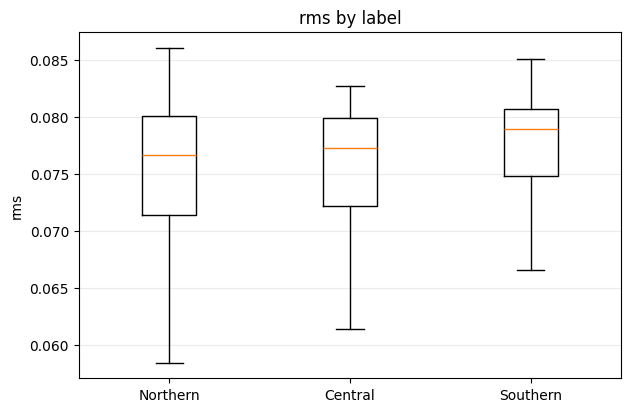

### `peak`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 80 | 0.6898 | 0.6599 | 0.1904 | 0.5383 |
| Central | 80 | 0.6726 | 0.6328 | 0.1843 | 0.5093 |
| Southern | 80 | 0.6536 | 0.6576 | 0.1865 | 0.5224 |

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_peak_boxplot.png


/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


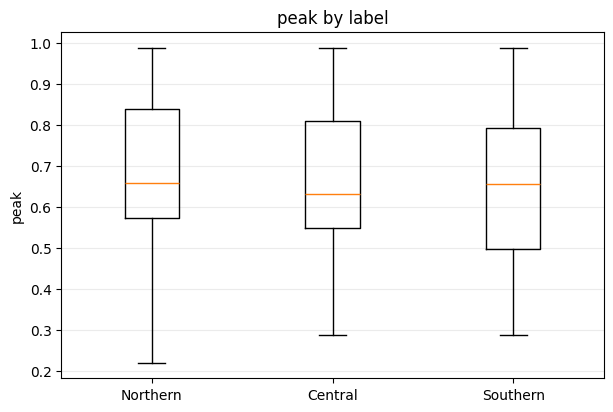

### `zcr`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 80 | 0.0905 | 0.0842 | 0.0388 | 0.0950 |
| Central | 80 | 0.0781 | 0.0746 | 0.0341 | 0.0621 |
| Southern | 80 | 0.0867 | 0.0839 | 0.0301 | 0.0695 |

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_zcr_boxplot.png


/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


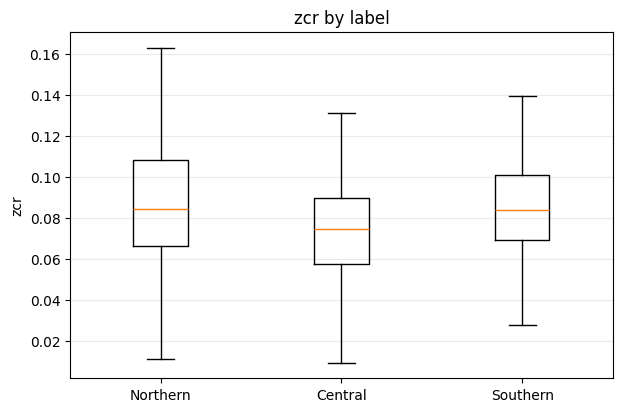

### `spectral_centroid_mean`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 80 | 616.4752 | 566.8940 | 275.8226 | 599.0616 |
| Central | 80 | 538.7777 | 500.4285 | 239.2508 | 430.3345 |
| Southern | 80 | 593.2555 | 583.7001 | 208.1274 | 445.7810 |

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_spectral_centroid_mean_boxplot.png


/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


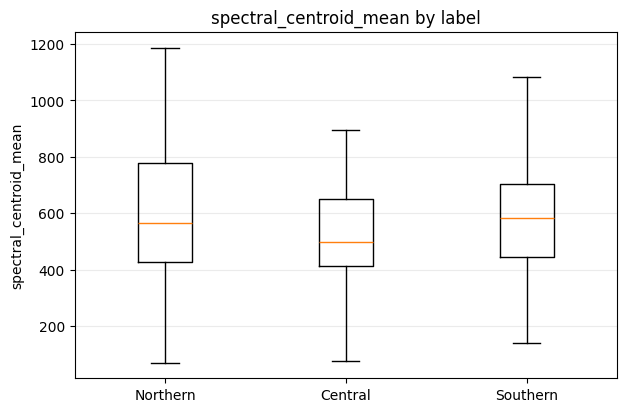

### `spectral_bandwidth_mean`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 80 | 518.4663 | 499.3457 | 213.0851 | 503.8841 |
| Central | 80 | 462.9152 | 437.4324 | 183.7604 | 348.9493 |
| Southern | 80 | 515.8159 | 509.8132 | 178.9338 | 404.7008 |

/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_spectral_bandwidth_mean_boxplot.png


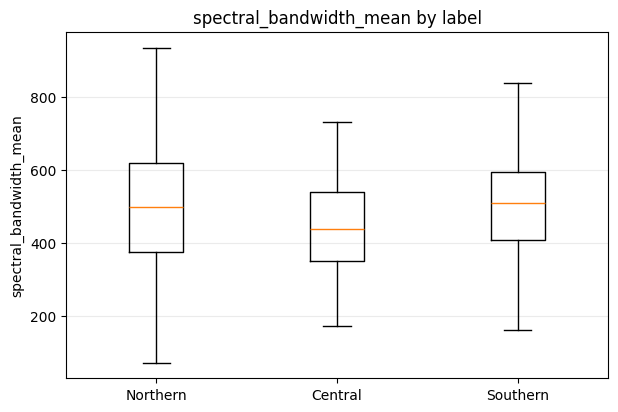

### `spectral_flatness_mean`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 80 | 0.1140 | 0.0298 | 0.1741 | 0.3141 |
| Central | 80 | 0.0973 | 0.0218 | 0.1532 | 0.3038 |
| Southern | 80 | 0.0753 | 0.0207 | 0.1279 | 0.1909 |

/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_spectral_flatness_mean_boxplot.png


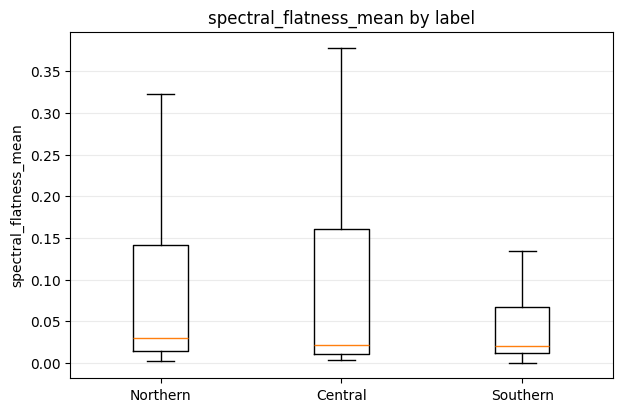

### `logmel_mean`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 80 | -11.8459 | -11.2525 | 2.3685 | 5.5199 |
| Central | 80 | -11.9704 | -11.6583 | 2.1024 | 4.6267 |
| Southern | 80 | -11.1673 | -10.8362 | 1.7658 | 3.9265 |

/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_logmel_mean_boxplot.png


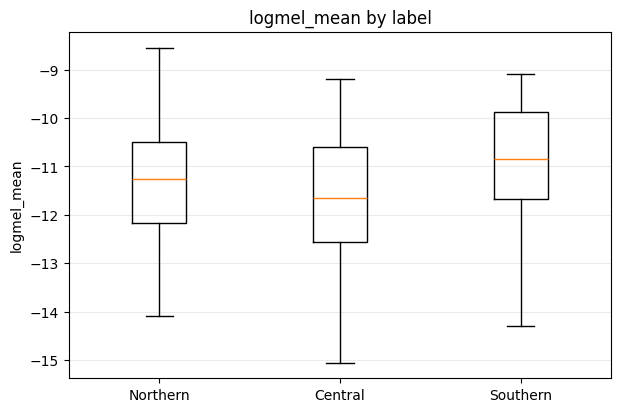

### `logmel_std`

| label | n | mean | median | std | p90_minus_p10 |
| --- | --- | --- | --- | --- | --- |
| Northern | 80 | 4.3333 | 3.9131 | 1.1562 | 3.0285 |
| Central | 80 | 4.5787 | 4.3489 | 1.1710 | 3.0190 |
| Southern | 80 | 4.1469 | 3.8196 | 1.0926 | 2.8305 |

/var/folders/mp/749x0vbs0zb_xkpc1p_7fh580000gn/T/ipykernel_73746/1403099266.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS, showfliers=False)


saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_logmel_std_boxplot.png


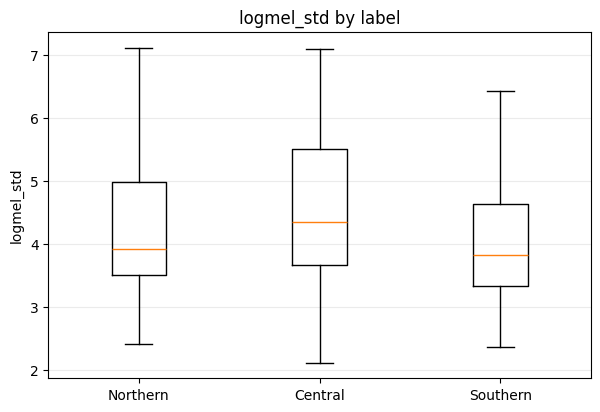

/Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/.venv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/.venv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/.venv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_feature_pca_by_label.png


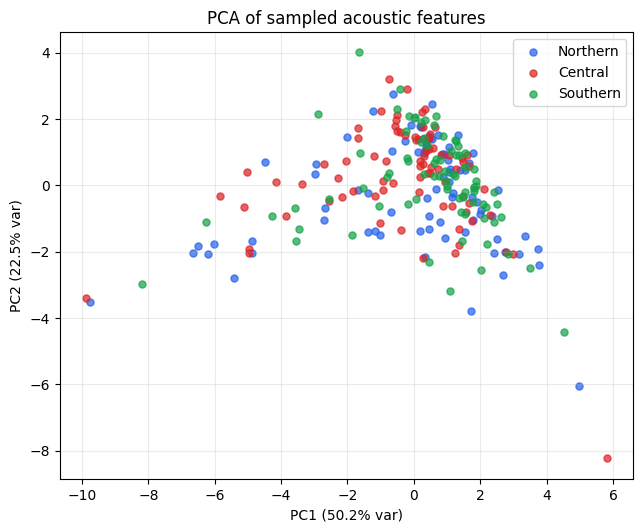

In [8]:
audio_feature_rows = [dict(row) for row in audio_feature_rows]
selected_feature_names = [
    "rms",
    "peak",
    "zcr",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_flatness_mean",
    "logmel_mean",
    "logmel_std",
    "mfcc_1_mean",
    "mfcc_2_mean",
    "mfcc_3_mean",
]
available_feature_names = [
    name
    for name in selected_feature_names
    if any(np.isfinite(as_float(row.get(name))) for row in audio_feature_rows)
]

for feature_name in available_feature_names[:8]:
    display(Markdown(f"### `{feature_name}`"))
    display_table(["label", "n", "mean", "median", "std", "p90_minus_p10"], summarize_numeric_by_label(audio_feature_rows, feature_name))
    plot_box_by_label(
        audio_feature_rows,
        feature_name,
        title=f"{feature_name} by label",
        ylabel=feature_name,
        output_name=f"audio_{feature_name}_boxplot.png",
    )

pca_summary: dict[str, Any] = {"available": False}
if len(audio_feature_rows) >= 6 and len(available_feature_names) >= 2:
    matrix = np.asarray(
        [[as_float(row.get(name), 0.0) for name in available_feature_names] for row in audio_feature_rows],
        dtype=float,
    )
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
    scaled = StandardScaler().fit_transform(matrix)
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    coords = pca.fit_transform(scaled)
    pca_summary = {
        "available": True,
        "explained_variance_ratio": pca.explained_variance_ratio_.tolist(),
    }

    plt.figure(figsize=(7.4, 5.8))
    colors = {"Northern": "#2563eb", "Central": "#dc2626", "Southern": "#16a34a"}
    for label in LABELS:
        idx = [i for i, row in enumerate(audio_feature_rows) if row.get("label") == label]
        if not idx:
            continue
        plt.scatter(coords[idx, 0], coords[idx, 1], s=26, alpha=0.72, label=label, color=colors[label])
    plt.title("PCA of sampled acoustic features")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
    plt.legend()
    plt.grid(alpha=0.25)
    acoustic_pca_path = save_current_figure("audio_feature_pca_by_label.png")
    plt.show()
else:
    display(Markdown("Không đủ audio feature để chạy PCA."))

## 7. Định lượng overlap bằng nearest centroid

PCA nhìn bằng mắt là hữu ích nhưng dễ chủ quan. Cell này dùng feature âm học đã scale, tính centroid của từng class, rồi xem mỗi mẫu gần centroid nào nhất. Đây là phép đo mô tả đơn giản:

- Nếu nhiều mẫu Central gần centroid Northern/Southern hơn centroid Central, điều đó ủng hộ giả thuyết Central overlap âm học.
- Nếu Central gần chính centroid Central nhưng E7 vẫn sai, nguyên nhân có thể nằm ở representation/model head hoặc nội dung/cue mà feature đơn giản chưa bắt được.

| true_label | near_Northern | near_Central | near_Southern | near_own_centroid_rate |
| --- | --- | --- | --- | --- |
| Northern | 15 | 28 | 37 | 0.1875 |
| Central | 10 | 38 | 32 | 0.4750 |
| Southern | 7 | 24 | 49 | 0.6125 |

saved: /Users/phatdatto/Working/School/speech_processing/Vietnamese-Dialect-Identification-Web-Application/outputs/figures/e7_central_error_analysis/audio_nearest_centroid_matrix.png


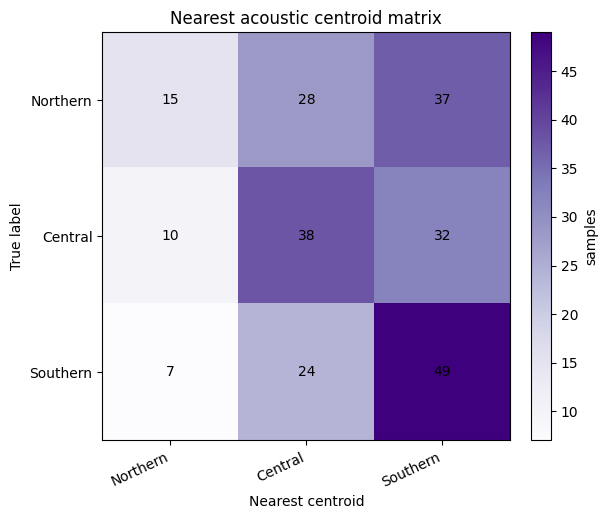

In [9]:
centroid_rows: list[list[Any]] = []
nearest_centroid_matrix = np.zeros((len(LABELS), len(LABELS)), dtype=int)
centroid_summary: dict[str, Any] = {"available": False}

if len(audio_feature_rows) >= 6 and len(available_feature_names) >= 2:
    matrix = np.asarray(
        [[as_float(row.get(name), 0.0) for name in available_feature_names] for row in audio_feature_rows],
        dtype=float,
    )
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
    scaled = StandardScaler().fit_transform(matrix)
    y = np.asarray([LABEL_TO_INDEX[row.get("label", "")] for row in audio_feature_rows], dtype=int)
    centroids = np.vstack([scaled[y == index].mean(axis=0) for index in range(len(LABELS))])
    distances = np.linalg.norm(scaled[:, None, :] - centroids[None, :, :], axis=2)
    nearest = distances.argmin(axis=1)
    for true_index, nearest_index in zip(y, nearest):
        nearest_centroid_matrix[true_index, nearest_index] += 1

    for i, label in enumerate(LABELS):
        row_total = max(int(nearest_centroid_matrix[i].sum()), 1)
        centroid_rows.append([
            label,
            int(nearest_centroid_matrix[i, 0]),
            int(nearest_centroid_matrix[i, 1]),
            int(nearest_centroid_matrix[i, 2]),
            float(nearest_centroid_matrix[i, i] / row_total),
        ])
    centroid_summary = {
        "available": True,
        "matrix": nearest_centroid_matrix.tolist(),
        "central_nearest_northern": int(nearest_centroid_matrix[LABEL_TO_INDEX["Central"], LABEL_TO_INDEX["Northern"]]),
        "central_nearest_central": int(nearest_centroid_matrix[LABEL_TO_INDEX["Central"], LABEL_TO_INDEX["Central"]]),
        "central_nearest_southern": int(nearest_centroid_matrix[LABEL_TO_INDEX["Central"], LABEL_TO_INDEX["Southern"]]),
    }
    display_table(["true_label", "near_Northern", "near_Central", "near_Southern", "near_own_centroid_rate"], centroid_rows)

    plt.figure(figsize=(6.5, 5.3))
    image = plt.imshow(nearest_centroid_matrix, cmap="Purples")
    plt.title("Nearest acoustic centroid matrix")
    plt.xlabel("Nearest centroid")
    plt.ylabel("True label")
    plt.xticks(range(len(LABELS)), LABELS, rotation=25, ha="right")
    plt.yticks(range(len(LABELS)), LABELS)
    for i in range(nearest_centroid_matrix.shape[0]):
        for j in range(nearest_centroid_matrix.shape[1]):
            plt.text(j, i, str(int(nearest_centroid_matrix[i, j])), ha="center", va="center")
    plt.colorbar(image, fraction=0.046, pad=0.04, label="samples")
    nearest_centroid_path = save_current_figure("audio_nearest_centroid_matrix.png")
    plt.show()
else:
    display(Markdown("Không đủ audio feature để tính nearest centroid."))

## 8. Tùy chọn nặng: chạy E7 forward để lấy confidence và embedding

Phần này dùng checkpoint E7, PhoWhisper cache, và audio test để sinh bảng prediction-level:

- `prob_Northern`, `prob_Central`, `prob_Southern`, `confidence`, `pred_label`,
- `error_type`, ví dụ `Central->Southern`,
- embedding `z_global`, `z_local`, `z_fused`, và gate `alpha` nếu gated.

Mặc định `RUN_E7_FORWARD = False` để notebook luôn chạy nhanh/offline. Khi cần phân tích sâu, đổi thành `True`. Nếu thiếu HF cache hoặc checkpoint, cell sẽ báo lỗi rõ ràng thay vì im lặng.

In [10]:
RUN_E7_FORWARD = False
FORWARD_SPLIT = "test"
FORWARD_LIMIT_PER_LABEL: int | None = 30
FORWARD_BATCH_SIZE = 4
FORWARD_DEVICE = "cpu"  # use "mps" outside sandbox if you want faster local execution


def select_forward_rows(rows: list[dict[str, str]]) -> list[dict[str, str]]:
    rng = random.Random(RANDOM_SEED)
    candidates = [row for row in rows if row.get("source_split") == FORWARD_SPLIT and row.get("label") in LABELS]
    selected: list[dict[str, str]] = []
    for label in LABELS:
        label_rows = [row for row in candidates if row.get("label") == label and safe_row_path(row).exists()]
        rng.shuffle(label_rows)
        if FORWARD_LIMIT_PER_LABEL is not None:
            label_rows = label_rows[:FORWARD_LIMIT_PER_LABEL]
        selected.extend(label_rows)
    return selected


def write_prediction_csv(path: Path, rows: list[dict[str, Any]]) -> None:
    if not rows:
        return
    fields = list(rows[0].keys())
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as output_file:
        writer = csv.DictWriter(output_file, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


if not RUN_E7_FORWARD:
    display(Markdown(
        "E7 forward section skipped. Đổi `RUN_E7_FORWARD = True` để sinh prediction/confidence/embedding artifacts."
    ))
else:
    import torch
    from types import SimpleNamespace

    from src.models.whisper_cnn_fusion import WhisperCnnFusionClassifier, infer_whisper_hidden_size
    from src.training.train_cnn import resolve_device, set_seed
    from src.training.train_e7_whisper_cnn_fusion import (
        build_loader,
        load_efficientnet_encoder,
        load_frozen_whisper_encoder,
    )

    if not CHECKPOINT_PATH.exists():
        raise FileNotFoundError(f"Missing E7 checkpoint: {CHECKPOINT_PATH}")
    set_seed(RANDOM_SEED)
    device = resolve_device(FORWARD_DEVICE)
    forward_rows = select_forward_rows(metadata_rows)
    display(Markdown(f"Running E7 forward for `{len(forward_rows)}` rows on `{device}`."))

    args = SimpleNamespace(
        model_id=results.get("model_id", "vinai/PhoWhisper-base"),
        cache_dir=ROOT / results.get("cache_dir", "outputs/models/hf_cache"),
        allow_download=False,
        cnn_checkpoint_path=ROOT / results.get("cnn_checkpoint_path", "outputs/models/e2_efficientnetb0_logmel.pt"),
        cnn_trainable_layers=int(results.get("training", {}).get("cnn_trainable_layers") or 0),
    )
    feature_extractor, whisper_encoder = load_frozen_whisper_encoder(args, device)
    local_encoder, _cnn_checkpoint = load_efficientnet_encoder(args, device)
    model = WhisperCnnFusionClassifier(
        whisper_encoder=whisper_encoder,
        whisper_hidden_size=infer_whisper_hidden_size(whisper_encoder),
        num_classes=len(LABELS),
        local_encoder=local_encoder,
        local_embedding_dim=int(results.get("fusion", {}).get("local_embedding_dim", 128)),
        fusion_dim=int(results.get("fusion", {}).get("fusion_dim", 512)),
        classifier_hidden_dim=int(results.get("fusion", {}).get("classifier_hidden_dim", 256)),
        fusion_type=results.get("fusion", {}).get("type", "gated"),
        dropout=0.0,
        freeze_local_encoder=True,
    ).to(device)
    model.enable_local_encoder_finetuning(args.cnn_trainable_layers)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    model.eval()

    loader = build_loader(
        forward_rows,
        feature_extractor,
        batch_size=FORWARD_BATCH_SIZE,
        shuffle=False,
        seed=RANDOM_SEED,
    )

    prediction_rows: list[dict[str, Any]] = []
    global_embeddings: list[np.ndarray] = []
    local_embeddings: list[np.ndarray] = []
    fused_embeddings: list[np.ndarray] = []
    alpha_embeddings: list[np.ndarray] = []
    cursor = 0
    with torch.no_grad():
        for batch in loader:
            whisper_features = batch["whisper_input_features"].to(device)
            logmel = batch["logmel"].to(device)
            labels_tensor = batch["label"].to(device)

            encoder_outputs = model.whisper_encoder(input_features=whisper_features)
            global_raw = encoder_outputs.last_hidden_state.mean(dim=1)
            local_raw = model.local_encoder(logmel)
            if local_raw.ndim > 2:
                local_raw = torch.flatten(local_raw, start_dim=1)
            projected_global = model.global_norm(global_raw)
            projected_local = model.local_projection(local_raw)
            if model.fusion_type == "gated":
                alpha = model.gate(torch.cat([projected_global, projected_local], dim=-1))
                fused = alpha * projected_global + (1.0 - alpha) * projected_local
            else:
                alpha = torch.empty((projected_global.shape[0], 0), device=device)
                fused = torch.cat([projected_global, projected_local], dim=-1)
            logits = model.classifier(fused)
            probs = torch.softmax(logits, dim=1)
            pred = probs.argmax(dim=1)

            batch_size = int(labels_tensor.shape[0])
            for offset in range(batch_size):
                source_row = forward_rows[cursor + offset]
                true_label = LABELS[int(labels_tensor[offset].cpu())]
                pred_label = LABELS[int(pred[offset].cpu())]
                prob_values = probs[offset].detach().cpu().numpy().astype(float)
                prediction_rows.append({
                    "sample_id": source_row.get("sample_id", ""),
                    "source_split": source_row.get("source_split", ""),
                    "province_name": source_row.get("province_name", ""),
                    "speaker_id": source_row.get("speaker_id", ""),
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "confidence": float(prob_values.max()),
                    "prob_Northern": float(prob_values[LABEL_TO_INDEX["Northern"]]),
                    "prob_Central": float(prob_values[LABEL_TO_INDEX["Central"]]),
                    "prob_Southern": float(prob_values[LABEL_TO_INDEX["Southern"]]),
                    "error_type": "correct" if true_label == pred_label else f"{true_label}->{pred_label}",
                })
            cursor += batch_size
            global_embeddings.append(projected_global.detach().cpu().numpy())
            local_embeddings.append(projected_local.detach().cpu().numpy())
            fused_embeddings.append(fused.detach().cpu().numpy())
            alpha_embeddings.append(alpha.detach().cpu().numpy())

    write_prediction_csv(PREDICTION_CSV, prediction_rows)
    np.savez_compressed(
        EMBEDDING_NPZ,
        z_global=np.vstack(global_embeddings),
        z_local=np.vstack(local_embeddings),
        z_fused=np.vstack(fused_embeddings),
        alpha=np.vstack(alpha_embeddings) if alpha_embeddings and alpha_embeddings[0].shape[1] else np.empty((len(prediction_rows), 0)),
        true_label=np.asarray([row["true_label"] for row in prediction_rows]),
        pred_label=np.asarray([row["pred_label"] for row in prediction_rows]),
        sample_id=np.asarray([row["sample_id"] for row in prediction_rows]),
    )
    display(Markdown(f"Saved predictions to `{PREDICTION_CSV}` and embeddings to `{EMBEDDING_NPZ}`."))

    error_counts = Counter(row["error_type"] for row in prediction_rows)
    display_table(["error_type", "count"], [[key, value] for key, value in error_counts.most_common()], float_digits=0)

E7 forward section skipped. Đổi `RUN_E7_FORWARD = True` để sinh prediction/confidence/embedding artifacts.

## 9. Kết luận tự động và report ngắn

Cell cuối gom các evidence chính thành report markdown. Report này là bản tóm tắt để đưa vào báo cáo/thảo luận; kết luận cuối vẫn nên dựa trên việc xem figure và, nếu cần, chạy phần E7 forward để có confidence/embedding.

In [11]:
finding_lines = [
    "# E7 Central Error Analysis Summary",
    "",
    "## E7 Test Confusion",
    "",
    f"- Accuracy: `{accuracy:.4f}`.",
    f"- Macro F1: `{macro_f1:.4f}`.",
    f"- Central recall: `{report['Central']['recall']:.4f}`.",
    f"- Central F1: `{report['Central']['f1-score']:.4f}`.",
    f"- Central -> Northern errors: `{central_to_northern}`.",
    f"- Central -> Southern errors: `{central_to_southern}`.",
    "",
    "## Dataset Signals To Inspect",
    "",
]

central_samples = label_counts.get("Central", 0)
northern_samples = label_counts.get("Northern", 0)
southern_samples = label_counts.get("Southern", 0)
finding_lines.append(f"- Samples: Northern `{northern_samples}`, Central `{central_samples}`, Southern `{southern_samples}`.")
finding_lines.append(f"- Unique speakers: Northern `{unique_speakers['Northern']}`, Central `{unique_speakers['Central']}`, Southern `{unique_speakers['Southern']}`.")
finding_lines.append(f"- Unique provinces: Northern `{unique_provinces['Northern']}`, Central `{unique_provinces['Central']}`, Southern `{unique_provinces['Southern']}`.")

central_entropy = next(row[2] for row in province_entropy_rows if row[0] == "Central")
max_other_entropy = max(row[2] for row in province_entropy_rows if row[0] != "Central")
if central_entropy >= max_other_entropy:
    finding_lines.append("- Central has the highest or tied-highest province entropy, which supports checking within-Central diversity.")
else:
    finding_lines.append("- Central province entropy is not the highest; Central difficulty may come more from boundary overlap/model representation than province spread alone.")

if centroid_summary.get("available"):
    finding_lines.extend([
        "",
        "## Acoustic Nearest-Centroid Signal",
        "",
        f"- Central nearest Northern: `{centroid_summary['central_nearest_northern']}`.",
        f"- Central nearest Central: `{centroid_summary['central_nearest_central']}`.",
        f"- Central nearest Southern: `{centroid_summary['central_nearest_southern']}`.",
    ])
    if centroid_summary["central_nearest_northern"] + centroid_summary["central_nearest_southern"] > centroid_summary["central_nearest_central"]:
        finding_lines.append("- More sampled Central audio is closer to non-Central acoustic centroids than to Central, supporting the overlap hypothesis.")
    else:
        finding_lines.append("- Most sampled Central audio remains closest to the Central acoustic centroid; inspect E7 embeddings/confidence for model-specific confusion.")

finding_lines.extend([
    "",
    "## Suggested Next Checks",
    "",
    "1. Run the optional E7 forward section to export prediction confidence and fused embeddings.",
    "2. Compare Central->Northern and Central->Southern samples by province and speaker.",
    "3. If Central errors are low-confidence, try central logit bias or class weighting.",
    "4. If Central errors are high-confidence, inspect embedding overlap and consider targeted augmentation/fine-tuning.",
    "",
    "## Generated Figures",
    "",
])
def path_for_display(path: Path) -> Path:
    try:
        return path.relative_to(ROOT)
    except ValueError:
        return path


for figure_path in sorted(FIG_DIR.glob("*.png")):
    finding_lines.append(f"- `{path_for_display(figure_path)}`")

REPORT_PATH.write_text("\n".join(finding_lines) + "\n", encoding="utf-8")
display(Markdown(f"Saved summary report to `{path_for_display(REPORT_PATH)}`."))
display(Markdown("\n".join(finding_lines[:40])))

Saved summary report to `outputs/reports/e7_central_error_analysis.md`.

# E7 Central Error Analysis Summary

## E7 Test Confusion

- Accuracy: `0.8025`.
- Macro F1: `0.7947`.
- Central recall: `0.5914`.
- Central F1: `0.6849`.
- Central -> Northern errors: `85`.
- Central -> Southern errors: `114`.

## Dataset Signals To Inspect

- Samples: Northern `4680`, Central `4390`, Southern `4824`.
- Unique speakers: Northern `3419`, Central `3022`, Southern `3101`.
- Unique provinces: Northern `24`, Central `19`, Southern `19`.
- Central province entropy is not the highest; Central difficulty may come more from boundary overlap/model representation than province spread alone.

## Acoustic Nearest-Centroid Signal

- Central nearest Northern: `10`.
- Central nearest Central: `38`.
- Central nearest Southern: `32`.
- More sampled Central audio is closer to non-Central acoustic centroids than to Central, supporting the overlap hypothesis.

## Suggested Next Checks

1. Run the optional E7 forward section to export prediction confidence and fused embeddings.
2. Compare Central->Northern and Central->Southern samples by province and speaker.
3. If Central errors are low-confidence, try central logit bias or class weighting.
4. If Central errors are high-confidence, inspect embedding overlap and consider targeted augmentation/fine-tuning.

## Generated Figures

- `outputs/figures/e7_central_error_analysis/audio_feature_pca_by_label.png`
- `outputs/figures/e7_central_error_analysis/audio_logmel_mean_boxplot.png`
- `outputs/figures/e7_central_error_analysis/audio_logmel_std_boxplot.png`
- `outputs/figures/e7_central_error_analysis/audio_nearest_centroid_matrix.png`
- `outputs/figures/e7_central_error_analysis/audio_peak_boxplot.png`
- `outputs/figures/e7_central_error_analysis/audio_rms_boxplot.png`